# Week 7 (Interim): Complex Model & Initial Benchmark

**Course:** Carisurg AI Programme

**Student:** Israel De La Mothe

**Input dataset:** `data/triage_clean_interim.csv` (same file used in Week 6)

## Objective

This is the **interim** submission for Week 7. It:

- Re-establishes the Week 6 baseline (dummy classifier, logistic regression, decision tree) using the *same* train/test split, so the comparison is fair.
- Trains one more-complex model — **Random Forest** — on the same features.
- Benchmarks baseline vs. complex model on the six quantitative axes (accuracy, precision, recall, F1, training time, inference time).
- Adds a first pass at the seventh, qualitative axis (interpretability), to be expanded in the final submission's memo.

The full write-up (cost-benefit memo, decision journal) is the final submission. This notebook is the evidence behind it.

## Why Random Forest

Random Forest was chosen over gradient boosting (XGBoost/LightGBM) or a small MLP for three reasons, to be weighed properly in the final memo:

1. It handles the same unscaled, sparse binary `cc_*` feature set as the Week 6 decision tree without extra preprocessing.
2. It gives a built-in, clinician-explainable interpretability path (feature importances, and single-tree traversal from within the forest) without needing an extra library like SHAP — though SHAP can be added later if the memo needs a stronger interpretability argument.
3. It is a lower operational risk step up from a single decision tree (variance reduction via bagging) before committing to the added complexity of boosting or a neural network.

This choice is not final — the cost-benefit memo will argue for or against it explicitly.


In [1]:
## Setup
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

RANDOM_SEED = 42  # unchanged from Week 6, for a fair comparison


## Load Cleaned Dataset

Same path-resolution logic as Week 6: relative path from repo root first, Colab/Drive fallback second.


In [2]:
REPO_RELATIVE_PATH = "data/triage_clean_interim.csv"
COLAB_FALLBACK_PATH = "/content/drive/MyDrive/Colab Notebooks/Carisurg/data/triage_clean_interim.csv"

DATA_PATH = REPO_RELATIVE_PATH if os.path.exists(REPO_RELATIVE_PATH) else COLAB_FALLBACK_PATH

df = pd.read_csv(DATA_PATH)
print(f"Loaded from: {DATA_PATH}")
print("Rows:", df.shape[0], "Columns:", df.shape[1])


Loaded from: data/triage_clean_interim.csv
Rows: 55121 Columns: 225


## Recreate Week 6 Target, Features, and Split

This block is copied from Week 6 unchanged. Reusing the identical target definition, feature set, and
`train_test_split` call (same `random_state`) is what makes the Week 7 comparison honest — the complex
model must beat the baseline on the same unseen patients, not on an easier split.


In [3]:
target_col = "esi"

# Drop columns that would leak the outcome — recorded at/after the triage decision.
drop_cols = ["disposition", "previousdispo"]

X = df.drop(columns=[target_col] + [c for c in drop_cols if c in df.columns])
y = df[target_col].astype(int)

# Same baseline scope as Week 6: numeric + already-binary cc_* features only.
X = X.select_dtypes(include=np.number)

print("Feature count:", X.shape[1])
print("Target distribution:")
print(y.value_counts().sort_index())


Feature count: 209
Target distribution:
esi
1       77
2    17924
3    27010
4     8896
5     1214
Name: count, dtype: int64


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_SEED
)

print("Train:", X_train.shape, "Test:", X_test.shape)


Train: (44096, 209) Test: (11025, 209)


In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## Re-run Week 6 Baselines (with timing)

Re-training here (rather than importing saved predictions) lets us measure training and inference time
on this machine, on equal footing with the Random Forest below.


In [6]:
def time_fit_predict(model, X_tr, y_tr, X_te):
    t0 = time.perf_counter()
    model.fit(X_tr, y_tr)
    train_time = time.perf_counter() - t0

    t0 = time.perf_counter()
    y_pred = model.predict(X_te)
    inference_time_total = time.perf_counter() - t0
    inference_time_per_pred = inference_time_total / len(X_te)

    return y_pred, train_time, inference_time_per_pred

# Model 1: Stratified random baseline
dummy = DummyClassifier(strategy="stratified", random_state=RANDOM_SEED)
y_pred_dummy, t_train_dummy, t_infer_dummy = time_fit_predict(dummy, X_train, y_train, X_test)

# Model 2: Logistic regression (scaled features)
logreg = LogisticRegression(max_iter=2000, solver="lbfgs", random_state=RANDOM_SEED)
y_pred_logreg, t_train_logreg, t_infer_logreg = time_fit_predict(
    logreg, X_train_scaled, y_train, X_test_scaled
)

# Model 3: Decision tree (unscaled features, same max_depth as Week 6)
tree = DecisionTreeClassifier(max_depth=6, random_state=RANDOM_SEED)
y_pred_tree, t_train_tree, t_infer_tree = time_fit_predict(tree, X_train, y_train, X_test)

print("Baselines re-trained.")


Baselines re-trained.


## Task 1: Train the Complex Model — Random Forest

`n_estimators=300` and `max_depth=None` (grown to purity, bounded only by `min_samples_leaf`) are a
reasonable starting point for a dataset this size; both should be revisited if training time or
overfitting (train/test accuracy gap) looks wrong once you run this on the real data.


In [7]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    random_state=RANDOM_SEED,
    n_jobs=-1
)

y_pred_rf, t_train_rf, t_infer_rf = time_fit_predict(rf, X_train, y_train, X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Random Forest Macro F1:", f1_score(y_test, y_pred_rf, average="macro"))
print()
print(classification_report(y_test, y_pred_rf, digits=3))


Random Forest Accuracy: 0.6760090702947846
Random Forest Macro F1: 0.41835471155437204

              precision    recall  f1-score   support

           1      0.000     0.000     0.000        16
           2      0.729     0.627     0.674      3585
           3      0.659     0.789     0.718      5402
           4      0.640     0.522     0.575      1779
           5      0.567     0.070     0.125       243

    accuracy                          0.676     11025
   macro avg      0.519     0.401     0.418     11025
weighted avg      0.676     0.676     0.667     11025



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Task 2: Six-Axis Benchmark

Accuracy, macro precision/recall/F1 (matching the Week 6 rationale — macro, not weighted, because
ESI Level 1 is rare and clinically the most dangerous class to get wrong), training time, and
per-prediction inference time, for all four models side by side.


In [8]:
def macro_precision(y_true, y_pred):
    return precision_score(y_true, y_pred, average="macro", zero_division=0)

def macro_recall(y_true, y_pred):
    return recall_score(y_true, y_pred, average="macro", zero_division=0)

benchmark = pd.DataFrame({
    "Model": ["Stratified Random", "Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_dummy),
        accuracy_score(y_test, y_pred_logreg),
        accuracy_score(y_test, y_pred_tree),
        accuracy_score(y_test, y_pred_rf),
    ],
    "Macro Precision": [
        macro_precision(y_test, y_pred_dummy),
        macro_precision(y_test, y_pred_logreg),
        macro_precision(y_test, y_pred_tree),
        macro_precision(y_test, y_pred_rf),
    ],
    "Macro Recall": [
        macro_recall(y_test, y_pred_dummy),
        macro_recall(y_test, y_pred_logreg),
        macro_recall(y_test, y_pred_tree),
        macro_recall(y_test, y_pred_rf),
    ],
    "Macro F1": [
        f1_score(y_test, y_pred_dummy, average="macro"),
        f1_score(y_test, y_pred_logreg, average="macro"),
        f1_score(y_test, y_pred_tree, average="macro"),
        f1_score(y_test, y_pred_rf, average="macro"),
    ],
    "Train Time (s)": [t_train_dummy, t_train_logreg, t_train_tree, t_train_rf],
    "Inference Time (s/pred)": [t_infer_dummy, t_infer_logreg, t_infer_tree, t_infer_rf],
})

benchmark


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Train Time (s),Inference Time (s/pred)
0,Stratified Random,0.375420,0.204053,0.203746,0.203876,0.003094,2.479411e-07
1,Logistic Regression,0.682812,0.606721,0.475614,0.507936,5.392796,1.409417e-06
2,Decision Tree,0.553832,0.263566,0.243459,0.213761,0.433827,6.374468e-07
3,Random Forest,0.676009,0.519027,0.401451,0.418355,32.933816,4.509312e-05


In [9]:
# Save the draft benchmark table for the interim submission (\docs)
os.makedirs("docs", exist_ok=True)
benchmark.to_csv("docs/week7_benchmark_draft.csv", index=False)
benchmark.round(4)


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Train Time (s),Inference Time (s/pred)
0,Stratified Random,0.3754,0.2041,0.2037,0.2039,0.0031,0.0
1,Logistic Regression,0.6828,0.6067,0.4756,0.5079,5.3928,0.0
2,Decision Tree,0.5538,0.2636,0.2435,0.2138,0.4338,0.0
3,Random Forest,0.6760,0.5190,0.4015,0.4184,32.9338,0.0


## ESI Level 1 Recall — the metric that matters most

Same rationale as Week 6: a missed Level 1 patient (false negative) is the highest-harm failure mode.
Macro F1 can hide poor performance on this one rare, critical class, so it is checked separately here.


In [10]:
def esi1_recall(y_true, y_pred):
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    return report.get("1", {}).get("recall", float("nan"))

esi1_table = pd.DataFrame({
    "Model": ["Stratified Random", "Logistic Regression", "Decision Tree", "Random Forest"],
    "ESI Level 1 Recall": [
        esi1_recall(y_test, y_pred_dummy),
        esi1_recall(y_test, y_pred_logreg),
        esi1_recall(y_test, y_pred_tree),
        esi1_recall(y_test, y_pred_rf),
    ],
})
esi1_table


,Model,ESI Level 1 Recall
0,Stratified Random,0.00
1,Logistic Regression,0.25
2,Decision Tree,0.00
3,Random Forest,0.00


**[Fill in after running the cells above]** — state which model has the best (and worst) ESI Level 1
recall, and by how much, in plain terms. This is the number the ED Board and Martina Griffith will
push on hardest: a complex model that improves macro F1 but *not* Level 1 recall is a much weaker case
for added compute cost.


## Task 2 (continued): Interpretability — First Pass

Two views, so a single Random Forest prediction can be explained to Dr. Reyes in under a minute:

1. **Global**: which features drive the forest's decisions overall (feature importances).
2. **Local**: for one patient, which features pushed the prediction, using a single tree from the forest
   as an illustrative traversal (a full per-prediction explanation via SHAP is left for the final memo,
   since it adds a dependency and compute cost that itself needs to be justified/benchmarked).


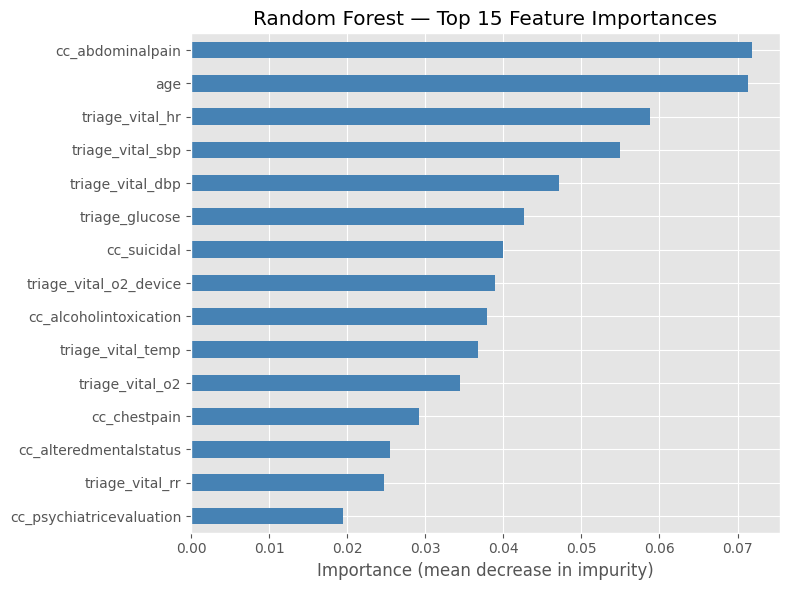

,0
cc_abdominalpain,0.071849
age,0.071339
triage_vital_hr,0.058750
triage_vital_sbp,0.054924
triage_vital_dbp,0.047098
triage_glucose,0.042685
cc_suicidal,0.039927
triage_vital_o2_device,0.038890
cc_alcoholintoxication,0.037914
triage_vital_temp,0.036740


In [11]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

top_n = 15
fig, ax = plt.subplots(figsize=(8, 6))
importances.head(top_n)[::-1].plot(kind="barh", ax=ax, color="steelblue")
ax.set_title(f"Random Forest — Top {top_n} Feature Importances")
ax.set_xlabel("Importance (mean decrease in impurity)")
plt.tight_layout()
plt.savefig("docs/week7_rf_feature_importances.png", dpi=150, bbox_inches="tight")
plt.show()

importances.head(top_n)


In [12]:
# Local explanation: pick one test-set patient and show a single tree's decision path
# alongside the forest's actual (majority-vote) prediction, as an interpretability worked example.
sample_idx = 0
sample_X = X_test.iloc[[sample_idx]]
sample_y_true = y_test.iloc[sample_idx]
sample_y_pred = rf.predict(sample_X)[0]

print("True ESI:", sample_y_true, " | Forest prediction:", sample_y_pred)
print()
print("Illustrative single-tree path (tree #0 of the forest):")
single_tree = rf.estimators_[0]
node_indicator = single_tree.decision_path(sample_X)
feature = single_tree.tree_.feature
threshold = single_tree.tree_.threshold

for node_id in node_indicator.indices:
    if feature[node_id] < 0:  # leaf node
        continue
    fname = X.columns[feature[node_id]]
    fval = sample_X.iloc[0, feature[node_id]]
    direction = "<=" if fval <= threshold[node_id] else ">"
    print(f"  {fname} = {fval:.2f} {direction} {threshold[node_id]:.2f}")


True ESI: 2  | Forest prediction: 2

Illustrative single-tree path (tree #0 of the forest):
  cc_psychiatricevaluation = 0.00 <= 0.50
  cc_shortnessofbreath = 1.00 > 0.50
  cc_nasalcongestion = 0.00 <= 0.50
  cc_coldlikesymptoms = 0.00 <= 0.50
  cc_fatigue = 0.00 <= 0.50
  triage_vital_o2 = 94.00 > 93.25
  cc_asthma = 0.00 <= 0.50
  triage_vital_o2 = 94.00 <= 97.25
  cc_chesttightness = 0.00 <= 0.50
  age = 55.00 <= 67.50
  triage_vital_hr = 98.00 <= 108.50
  triage_vital_o2_device = 1.00 > 0.50


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(


**[Fill in after running the cell above]** — write the one-minute, clinician-facing explanation of
this single prediction in plain English (2–3 sentences), the way you would say it out loud to Dr. Reyes.
This is the interpretability evidence for the cost-benefit memo's "three arguments against" section if
the forest turns out harder to explain quickly than the Week 6 decision tree.


## Confusion Matrix — Random Forest


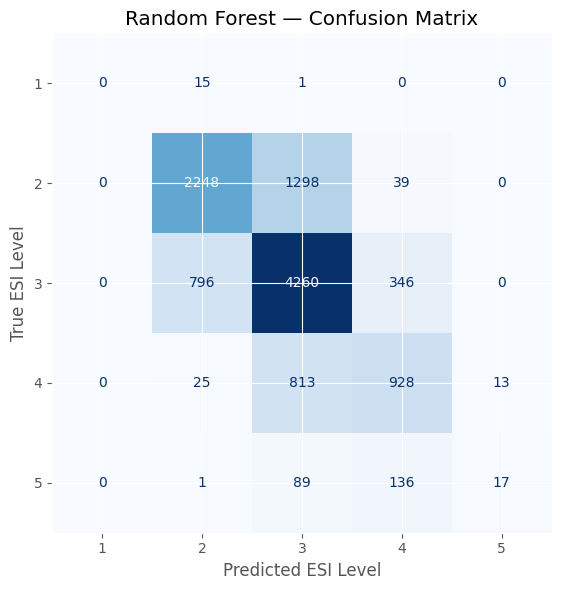

In [13]:
esi_labels = sorted(y.unique())

cm = confusion_matrix(y_test, y_pred_rf, labels=esi_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=esi_labels)

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_xlabel("Predicted ESI Level")
ax.set_ylabel("True ESI Level")
ax.set_title("Random Forest — Confusion Matrix")
plt.tight_layout()
plt.savefig("docs/week7_confusion_matrix_rf.png", dpi=150, bbox_inches="tight")
plt.show()


## Interim Conclusion (draft — expand in the final cost-benefit memo)

**[Fill in after running all cells above with the real dataset.]** As a checklist for the interim
submission, make sure you can state:

- Does Random Forest beat the Week 6 decision tree / logistic regression on macro F1? By how much?
- Does it beat them on ESI Level 1 recall specifically — the metric that matters most clinically?
- How much more expensive is it to train and to run per prediction, in absolute terms (seconds), not
  just relatively?
- Is the single-tree / feature-importance explanation still a "one-minute, clinician-facing" explanation,
  or does it already feel like it needs SHAP to be honest?

These four answers are the raw material for the final memo's verdict, three-for/three-against, and
risk/unknowns sections — they are not the memo itself.

**Things not yet known (carry into the decision journal):**

- Whether these results hold up under cross-validation rather than a single train/test split.
- Whether hyperparameter tuning (e.g. `max_depth`, `n_estimators`) would change the trade-off enough to
  matter, or whether the current defaults are "good enough" for a first honest comparison.
